In [2]:
import numpy as np
import pandas as pd

# Plantilla

Es necesario ajustar las definiciones, las fuentes de los datos y posiblemente definiciones si la ENEMDU tiene una dimensión geográfica y temporal al mismo tiempo

In [3]:
# data = pd.read_stata(r"Z:\harmonized\ECU\ENEMDU\data_arm\ECU_1990m11_BID.dta") # para bases de stata
data = pd.read_stata(r"datos/ECU_1990m11_BID.dta") # para bases de stata

## Revisar los datos

- rn - región natural
- estrato - estrato
- cuidad - ciudad
- zona - zona
- sector - sector
- conglo - conglomerado
- area - area
- vivienda - vivienda
- hogar - hogar
- persona - persona
- numpers - número de personas
- edad - edad
- ingesper - ingreso esperado por ese trabajo
- salbasic - salario básico (puede ser usarlo para discrimnar regiones)
- rulpago - cuánto recibió en el último pago (puede ser mejor que ingesper)
- gefec - cuánto retiro de su negocio en efectivo
- gmerc - cuánto retiro de su negocio en mercaderías
- valren - valor de ingreso por rentas
- valjub - valor de ingreso por jubilación
- valoti - valor de otros ingresos
- fexp - factor de expansión
- ingrl - ingreso (suma gefec y gmerc)

El valor de 'salbasic' es el ingreso laboral monetario, no hay datos sobre ingreso laboral no monetario hay relación entre 'salbasic' y 'rulpago' y 'formapago'.
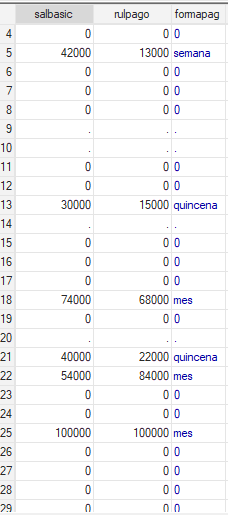 

Hay variables dicotomicas para cada mes (ene, feb, mar, abr, may, jun, jul, ago, sep, oct, nov, dic) que dicen si estuvo o no ocupado, se puede usar estas variables y el salario básico asumiendo que cuando estaba ocupado tenía ese salario para intentar aproximar el salario mensual y de ahí el salario trimestral, esto solo funciona así ya que no tenemos una variable que explicite el mes, en encuestas que tengan el mes o trimestre explícito esto no sería igual.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37216 entries, 0 to 37215
Columns: 247 entries, region_BID_c to ppp_wdi2011
dtypes: category(77), float32(16), float64(112), int16(7), int32(1), int8(29), object(5)
memory usage: 39.9+ MB


Filtramos solo las columnas de interés para alivar el peso en la memoria

In [5]:
data.columns

Index(['region_BID_c', 'region_c', 'pais_c', 'anio_c', 'mes_c', 'zona_c',
       'factor_ch', 'idh_ch', 'idp_ci', 'factor_ci',
       ...
       'secins', 'subequ', 'ingrl', 'peamsiu', 'contrato_ci', 'segsoc_ci',
       'formal', 'formal_1', 'ynlm_ci1', 'ppp_wdi2011'],
      dtype='object', length=247)

In [6]:
data = data[['rn', 'estrato', 'ciudad', 'zona', 'sector', 'conglo', 'area', 'vivienda', 'hogar', 'persona', 'numpers', 'edad', 'ingesper', 'salbasic', 'rulpago',
      'gefec', 'gmerc', 'valren', 'valjub', 'valoti', 'fexp', 'ingrl', 'ene', 'feb', 'mar', 'abr', 'may', 'jun', 'jul', 'ago', 'sep', 'oct', 'nov', 'dic']]

Ingreso mensual asumiendo que las personas reciben el mismo valor reportado en 'salbasic' siempre que reportan estar ocupados en un mes

In [7]:
data['ingr_ene'] = data.apply(lambda x: x['salbasic'] if x['ene'] == 'ocupado' else None, axis=1)
data['ingr_feb'] = data.apply(lambda x: x['salbasic'] if x['feb'] == 'ocupado' else None, axis=1)
data['ingr_mar'] = data.apply(lambda x: x['salbasic'] if x['mar'] == 'ocupado' else None, axis=1)
data['ingr_abr'] = data.apply(lambda x: x['salbasic'] if x['abr'] == 'ocupado' else None, axis=1)
data['ingr_may'] = data.apply(lambda x: x['salbasic'] if x['may'] == 'ocupado' else None, axis=1)
data['ingr_jun'] = data.apply(lambda x: x['salbasic'] if x['jun'] == 'ocupado' else None, axis=1)
data['ingr_jul'] = data.apply(lambda x: x['salbasic'] if x['jul'] == 'ocupado' else None, axis=1)
data['ingr_ago'] = data.apply(lambda x: x['salbasic'] if x['ago'] == 'ocupado' else None, axis=1)
data['ingr_sep'] = data.apply(lambda x: x['salbasic'] if x['sep'] == 'ocupado' else None, axis=1)
data['ingr_oct'] = data.apply(lambda x: x['salbasic'] if x['oct'] == 'ocupado' else None, axis=1)
data['ingr_nov'] = data.apply(lambda x: x['salbasic'] if x['nov'] == 'ocupado' else None, axis=1)
data['ingr_dic'] = data.apply(lambda x: x['salbasic'] if x['dic'] == 'ocupado' else None, axis=1)

Ingreso mensual promedio en el trimeste

In [8]:
data['ingr_t1'] = (data['ingr_ene'] + data['ingr_feb'] + data['ingr_mar'])/3
data['ingr_t2'] = (data['ingr_abr'] + data['ingr_may'] + data['ingr_jun'])/3
data['ingr_t3'] = (data['ingr_jul'] + data['ingr_ago'] + data['ingr_sep'])/3
data['ingr_t4'] = (data['ingr_oct'] + data['ingr_nov'] + data['ingr_dic'])/3

## Corregimos los valores de ser necesario

In [9]:
# Llenar valores perdidos con un dato (0)
data['ingr_t1'] = data['ingr_t1'].fillna(0)
data['ingr_t2'] = data['ingr_t2'].fillna(0)
data['ingr_t3'] = data['ingr_t3'].fillna(0)
data['ingr_t4'] = data['ingr_t4'].fillna(0)

## Deflactamos y transformamos el ingreso

Esto deja todo en dólares constantes de 2014

In [10]:
# Carga base de datos con ipc
data_externa = pd.read_excel("data_externa.xlsx", sheet_name='datos')

# filtra año de interés
datos_actual = data_externa[data_externa['Año'] == 1990]
datos_base = data_externa[data_externa['Año'] == 2014]

Diccionarios de ipc y tipo de cambio

In [11]:
ipc_dict = {fila['trimestre']: {
        'Nacional': fila['Nacional'],
        'Guayaquil': fila['Guayaquil'],
        'Quito': fila['Quito'],
        'Cuenca': fila['Cuenca']
    }
     for _, fila in datos_actual.iterrows()
     }

ipc_base_dict = {fila['trimestre']: {
        'Nacional': fila['Nacional'],
        'Guayaquil': fila['Guayaquil'],
        'Quito': fila['Quito'],
        'Cuenca': fila['Cuenca']
    }
     for _, fila in datos_base.iterrows()
     }

tipo_cambio_dict = dict(zip(datos_actual['trimestre'], datos_actual['tipo de cambio']))

### Creamos identificadores para las ciudades siguiendo los códigos del INEC y para los trimestres

In [12]:
# Corregimos los códigos para usarlos cómo texto
data['ciudad'] = data['ciudad'].apply(str)
data['ciudad'] = data['ciudad'].apply(lambda x: '0' + x if len(x) == 5 else x)

data['ciudad_2'] = data['ciudad'].apply(lambda x: x[:2])

Diccionario ciudades disponibles

In [13]:
parroquia_dict = {
    '01': 'Cuenca',
    '09': 'Guayaquil',
    '17': 'Quito'
}

data['ciudad_asignada'] = data['ciudad_2'].apply(lambda x: parroquia_dict.get(x, 'Nacional'))

Elegimos el trimestre según las variables del INEC donde sea igual a 'Ocuapdo'

In [14]:
def assgna_trimestre(fila):
    if 'ocupado' in [fila['ene'], fila['feb'], fila['mar']]:
        return 1
    elif 'ocupado' in [fila['abr'], fila['may'], fila['jun']]:
        return 2
    elif 'ocupado' in [fila['jul'], fila['ago'], fila['sep']]:
        return 3
    elif 'ocupado' in [fila['oct'], fila['nov'], fila['dic']]:
        return 4
    else:
        return None
    
data['trimestre'] = data.apply(assgna_trimestre, axis=1)

### Asignamos el ipc y tipo de cambio correspondiente según trimestre y ciudad correspondiente

$\begin{equation}
    ingr_{USD-base-2014}^{i} = \frac{ingr_{sucres}^{i}}{tipo-de-cambio^{i}}\left( \frac{ipc^{i}_{2014}}{ipc^{i}_{año}}\right)
\end{equation}$

Con $i$ el trimestre de interés y $año$ el año de interés

In [15]:
# Función que asigna valores correspondientes
def asigna_ipc(fila):
    return ipc_dict.get(fila['trimestre'], {}).get(fila['ciudad_asignada'], None)

def asigna_ipc_base(fila):
    return ipc_base_dict.get(fila['trimestre'], {}).get(fila['ciudad_asignada'], None)

In [16]:
data['ipc'] = data.apply(asigna_ipc, axis=1)
data['ipc_base'] = data.apply(asigna_ipc_base, axis=1)
data['tipo_cambio'] = data['trimestre'].map(tipo_cambio_dict)

In [17]:
# Calculamos el deflactor
data['def'] = (data['ipc_base'] / data['ipc'])

In [18]:
data['ingr_t1_r'] = (data['ingr_t1'] / data['tipo_cambio']) * data['def']
data['ingr_t2_r'] = (data['ingr_t2'] / data['tipo_cambio']) * data['def']
data['ingr_t3_r'] = (data['ingr_t3'] / data['tipo_cambio']) * data['def']
data['ingr_t4_r'] = (data['ingr_t4'] / data['tipo_cambio']) * data['def']

In [19]:
data[['ingr_t1', 'ingr_t2', 'ingr_t3', 'ingr_t4', 'ipc', 'ipc_base', 'def', 'tipo_cambio', 'ingr_t1_r', 'ingr_t2_r', 'ingr_t3_r', 'ingr_t4_r']]

,ingr_t1,ingr_t2,ingr_t3,ingr_t4,ipc,ipc_base,def,tipo_cambio,ingr_t1_r,ingr_t2_r,ingr_t3_r,ingr_t4_r
0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,0.0,0.0,0.0,0.951320,97.862086,102.869772,720.200000,0.000000,0.000000,0.000000,0.000000
4,42000.0,42000.0,42000.0,42000.0,0.951320,97.862086,102.869772,720.200000,5999.070292,5999.070292,5999.070292,5999.070292
...,...,...,...,...,...,...,...,...,...,...,...,...
37211,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37212,0.0,0.0,0.0,0.0,1.129234,98.871693,87.556418,831.503333,0.000000,0.000000,0.000000,0.000000
37213,75000.0,75000.0,75000.0,75000.0,1.129234,98.083034,86.858016,720.200000,9045.197476,9045.197476,9045.197476,9045.197476
37214,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Calculo ingreso de los hogares

In [20]:
columnas_idef = ['rn', 'estrato', 'ciudad', 'zona', 'sector', 'conglo', 'area', 'vivienda', 'hogar']

data['idef_hogar'] = data[columnas_idef].astype(str).agg(''.join, axis=1)
len(data['idef_hogar'].unique())

7910

In [21]:
data[['rn', 'estrato', 'ciudad', 'zona', 'sector', 'conglo', 'area', 'vivienda', 'hogar', 'idef_hogar', 'persona', 'numpers']]

,rn,estrato,ciudad,zona,sector,conglo,area,vivienda,hogar,idef_hogar,persona,numpers
0,1,3,010150,1,5,01,1,1,1,130101501501111,3,3
1,1,3,010150,1,5,01,1,1,1,130101501501111,2,3
2,1,3,010150,1,5,01,1,1,1,130101501501111,1,3
3,1,3,010150,1,5,01,1,2,1,130101501501121,2,2
4,1,3,010150,1,5,01,1,2,1,130101501501121,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...
37211,3,4,210450,1,11,01,1,12,1,34210450111011121,5,6
37212,3,4,210450,1,11,01,1,12,1,34210450111011121,2,6
37213,3,4,210450,1,11,01,1,12,1,34210450111011121,1,6
37214,3,4,210450,1,11,01,1,12,1,34210450111011121,3,6


In [22]:
data['ingr_t1_h'] = data.groupby('idef_hogar')['ingr_t1_r'].transform('sum')
data['ingr_t2_h'] = data.groupby('idef_hogar')['ingr_t2_r'].transform('sum')
data['ingr_t3_h'] = data.groupby('idef_hogar')['ingr_t3_r'].transform('sum')
data['ingr_t4_h'] = data.groupby('idef_hogar')['ingr_t4_r'].transform('sum')

In [23]:
data[['ingr_t1_h', 'ingr_t2_h', 'ingr_t3_h', 'ingr_t4_h']]

,ingr_t1_h,ingr_t2_h,ingr_t3_h,ingr_t4_h
0,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,5999.070292,5999.070292,5999.070292,5999.070292
4,5999.070292,5999.070292,5999.070292,5999.070292
...,...,...,...,...
37211,9045.197476,9045.197476,9045.197476,9045.197476
37212,9045.197476,9045.197476,9045.197476,9045.197476
37213,9045.197476,9045.197476,9045.197476,9045.197476
37214,9045.197476,9045.197476,9045.197476,9045.197476


In [24]:
print("Ingreso medio de un hogar t4: ", data['ingr_t4_h'].mean())
print("Mediana del ingreso de un hogar t4: ", data['ingr_t4_h'].median())

Ingreso medio de un hogar t4:  6735.162096291781
Mediana del ingreso de un hogar t4:  4407.441282677611


## Sacamos edades negativas y mayores a 100 años

In [25]:
len(data)

37216

En este caso en la variable edad tenemos números y el texto 'menos de un año' así que primero transformamos todas las filas que digan 'menos de un año' a 0

In [26]:
data['edad'] = data['edad'].apply(lambda x: x if type(x) == int else 0)

In [27]:
data = data.loc[(data['edad'] >= 0) & (data['edad'] < 100)]
len(data)

37216

## Ingreso individual descontando cargas familiares

Utilizando la metodología del autor dividimos el ingreso del hogar para la escala $(A_{i}+kC_{i})^{s}$ donde $A_{i}$ es al número de adultos, $C_{i}$ es el número de niños en el hogar $i$. $k$ es el costo en recursos de cada niño y $s$ busca reflejar las restricciones

In [31]:
k = 0.4
s = 0.9

In [32]:
# Si es necesario calcular el número de niños
data['es_nino'] = data['edad'] < 10

data['ninos'] = data.groupby('idef_hogar')['es_nino'].transform('sum')

# Si es necesario calcular el número de adultos
data['es_adulto'] = data['edad'] > 10

data['adultos'] = data.groupby('idef_hogar')['es_adulto'].transform('sum')

In [33]:
data['escala'] = (data['adultos'] + k * data['ninos']) ** s

In [34]:
data['ingr_t_t1'] = data['ingr_t1_h'] / data['escala']
data['ingr_t_t2'] = data['ingr_t2_h'] / data['escala']
data['ingr_t_t3'] = data['ingr_t3_h'] / data['escala']
data['ingr_t_t4'] = data['ingr_t4_h'] / data['escala']

In [35]:
data[['ingr_t_t1', 'ingr_t_t2', 'ingr_t_t3', 'ingr_t_t4']]

,ingr_t_t1,ingr_t_t2,ingr_t_t3,ingr_t_t4
0,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,3214.822170,3214.822170,3214.822170,3214.822170
4,3214.822170,3214.822170,3214.822170,3214.822170
...,...,...,...,...
37211,2855.918451,2855.918451,2855.918451,2855.918451
37212,2855.918451,2855.918451,2855.918451,2855.918451
37213,2855.918451,2855.918451,2855.918451,2855.918451
37214,2855.918451,2855.918451,2855.918451,2855.918451


In [36]:
print("Ingreso individual descontando cargas familiares t4: ", data['ingr_t_t4'].mean())
print("Mediana del ingreso individual descontando cargas familiares t4: ", data['ingr_t_t4'].median())

Ingreso individual descontando cargas familiares t4:  1777.6551603112619
Mediana del ingreso individual descontando cargas familiares t4:  1193.5123358433866


## Umbrales de pobreza

Incluimos los índices de pobreza si es posible a nivel regional para luego poder utilizar de mejor forma el factor de expansión

$\begin{equation}
    umbral_{USD-base-2014}^{i} = umbral_{año}\left( \frac{ipc^{i}_{2014}}{ipc^{i}_{año}}\right)
\end{equation}$

Con $i$ el trimestre de interés y $año$ el año de interés

Diccionario de umbral

In [37]:
umbral_dict = dict(zip(datos_actual['trimestre'], datos_actual['umbral de pobreza']))

In [38]:
# Asigna el umbral por trimestre si hay umbral por región modificar
data['umbral'] = data['trimestre'].map(umbral_dict)

data['umbral'] = data.groupby('idef_hogar')['umbral'].transform('mean')

## Cálculo del índice de pobreza de Foster, Greer y Thorbecke

Para calcular un ínidce de pobreza se utiliza a Foster, Greer y Thorbecke (1984), ya que satisface algunas caracterísitcas de distribución que son positivas e igual a las enunciadas por Sen, el autor usa el mismo índice.

$\begin{equation}FGT_{\alpha} = \frac{1}{N}\sum_{i=1}^{H}\left(\frac{z-y_{i}}{z}\right)^{\alpha}\end{equation}$

Donde $z$ es el umbral de pobreza, $N$ es el número de personas en la economía, $H$ es el número de pobres (personas debajo de la línea de pobreza) $y_{i}$ es el ingreso de cada individuo. Mientras mayor es el valor de $\alpha$ mayor es el peso de los individuos más pobres, mayor $FGT$ mayor pobreza en la economía.

En este caso los umbrales están anivel nacional, aún así buscamos calcular la pobreza por región y sacar un promedio ponderado por región para la pobreza nacional, con el objetivo de hacerlo más específico

In [334]:
datos_final = pd.DataFrame(index=['t1', 't2', 't3', 't4'], columns=['fgt0', 'fgt1', 'fgt2', 'a25', 'a50', 'a75', 'ingreso_promedio'])

In [335]:
for t in [1, 2, 3, 4]:
    condicion = data['trimestre'] == t
    col_ingr = f'ingr_t_t{t}'
    col_pobres = f'pobres_t{t}'

    # una columna que identifica a quienes están por debajo de la línea de pobreza por trimestre
    data[col_pobres] = (data.loc[condicion, col_ingr] - data.loc[condicion, 'umbral']) < 0

In [336]:
print("pobreza t1: ", data['pobres_t1'].sum()/len(data.loc[data['trimestre'] == 1]))
print("pobreza t2: ", data['pobres_t2'].sum()/len(data.loc[data['trimestre'] == 2]))
print("pobreza t3: ", data['pobres_t3'].sum()/len(data.loc[data['trimestre'] == 3]))
print("pobreza t4: ", data['pobres_t4'].sum()/len(data.loc[data['trimestre'] == 4]))

pobreza t1:  0.3780745930953945
pobreza t2:  0.47717842323651455
pobreza t3:  0.4161073825503356
pobreza t4:  0.48936170212765956


In [337]:
for t in [1, 2, 3, 4]:
    # Filtramos para cada trimestre
    df_temp = data.loc[data['trimestre'] == t].copy()

    # Calculamos una columna de pobres
    df_temp['pobres'] = (df_temp[f'ingr_t_t{t}'] - umbral_dict[t]) < 0

    # Ratio de pobres sobre el total
    ratio = (umbral_dict[t] - df_temp[f'ingr_t_t{t}']) / umbral_dict[t]

    # Calculamos el índice para alpha 0, 1 y 2 solo donde 'pobres' == True.
    for i in range(3):
        col = f'fgt{i}'
        df_temp[col] = np.where(df_temp['pobres'], ratio**i, 0)

    # Ratio de pobres cón el índice total
    fgt0 = df_temp['fgt0'].sum() / len(df_temp)
    fgt1 = df_temp['fgt1'].sum() / len(df_temp)
    fgt2 = df_temp['fgt2'].sum() / len(df_temp)

    # Guardamos los resultados
    datos_final.loc[f't{t}', 'fgt0'] = fgt0
    datos_final.loc[f't{t}', 'fgt1'] = fgt1
    datos_final.loc[f't{t}', 'fgt2'] = fgt2

In [338]:
datos_final

,fgt0,fgt1,fgt2,a25,a50,a75,ingreso_promedio
t1,0.378075,0.314976,0.29936,NaN,NaN,NaN,NaN
t2,0.481328,0.357709,0.333488,NaN,NaN,NaN,NaN
t3,0.416107,0.323227,0.299634,NaN,NaN,NaN,NaN
t4,0.489362,0.396668,0.373493,NaN,NaN,NaN,NaN


## Calculo del índice de desigualdad de Atkinson

Vamos a calcular el índice de desigualdad de atkinson con un parámetro $\epsilon$ de aversión a la desigualdad y un $\mu$ que es igual a la media de los ingresos individuales, con la siguiente fórmula.

$\begin{equation}A = 1-\frac{1}{\mu}\left(\frac{1}{N}\sum_{i=1}^{N}y^{1-\epsilon}\right)^{1/(1-\epsilon)}\end{equation}$

Donde $y_{i}$ es el ingreso individual y $\mu$ es el ingreso medio

In [339]:
for t in [1, 2, 3, 4]:
    # Filtramos para cada trimestre
    df_temp = data.loc[data['trimestre'] == t].copy()

    # Calculamos el ingreso promedio
    mu = df_temp[f'ingr_t_t{t}'].mean()

    # Calculamos el índice para epsilon 0.25, 0.5 y 0.75.
    for i in [0.25, 0.5, 0.75]:
        col = f'A{i}'
        df_temp[col] = ((df_temp[f'ingr_t_t{t}']**(1-i)).sum() / len(df_temp))**(1/(1-i))

    # Ratio de pobres cón el índice total
    a25 = 1 - 1/mu * df_temp['A0.25'].mean()
    a50 = 1 - 1/mu * df_temp['A0.5'].mean()
    a75 = 1 - 1/mu * df_temp['A0.75'].mean()

    # Guardamos los resultados
    datos_final.loc[f't{t}', 'a25'] = a25
    datos_final.loc[f't{t}', 'a50'] = a50
    datos_final.loc[f't{t}', 'a75'] = a75

In [340]:
datos_final

,fgt0,fgt1,fgt2,a25,a50,a75,ingreso_promedio
t1,0.378075,0.314976,0.29936,0.178964,0.395505,0.714967,NaN
t2,0.481328,0.357709,0.333488,0.184219,0.408729,0.736746,NaN
t3,0.416107,0.323227,0.299634,0.166144,0.375306,0.696762,NaN
t4,0.489362,0.396668,0.373493,0.188343,0.432239,0.781554,NaN


Guardamos el ingreso promedio

In [341]:
for t in [1, 2, 3, 4]:
    df_temp = data.loc[data['trimestre'] == t].copy()

    datos_final.loc[f't{t}', 'ingreso_promedio'] = df_temp[f'ingr_t_t{t}'].mean()

In [343]:
datos_final

,fgt0,fgt1,fgt2,a25,a50,a75,ingreso_promedio
t1,0.378075,0.314976,0.29936,0.178964,0.395505,0.714967,2125.750575
t2,0.481328,0.357709,0.333488,0.184219,0.408729,0.736746,1432.260625
t3,0.416107,0.323227,0.299634,0.166144,0.375306,0.696762,1613.627981
t4,0.489362,0.396668,0.373493,0.188343,0.432239,0.781554,1407.631398


In [344]:
datos_final.to_csv('datos_final.csv')